``` py

!pip install takeHomeTest
import takeHomeTest

!pip install time
from time import oneWeek as panic

panic.dump(takeHomeTest)


print("Welcome to your take home final!\n")
```

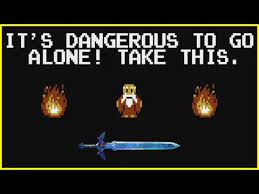




## ------------------------------------------- The Legend of Python --------------------------------------------
**Lore**

In the Kingdom of Pyrovia, all nations once traded in harmony. But since the Shattering of the Global APIs, the knowledge of currency exchange — locked away in XML scrolls — has scattered across the timelines. These scrolls reside in a mysterious repository known only as floatrates.com.

The High Council of Programmers has summoned you (and only you), young code-wielder, to begin your final trial. It is divided into 2 parts.
* Quest 1 (50xp): Retrieving the scrolls of time - Threading and Json save and parsing
* Quest 2 (50xp): Decipher the scrolls - Perform EDA on the data.

------ ------ ------ ------ Extra credit ------ ------ ------ ------ 
* Side Quest 1 (10xp*): Lay down seeds for those that follow - create error logs 
* Side Quest 2 (10xp*): The Quest of reflection  - Use profiling on your code to fully understand it 

*any points over 100% will be rolled over into your final grade. 

I may not have time to run all of your code so make sure you very clearly take notes and communicate successes, issues, and lessons learned. 
Please stay off Chat GPT and stack overflow (and like). You should have most everything you need in the notes. 

--------------------------------------------
# Quest 1 (50 xp): Retrieving the Scrolls of Time 
Retrieve historical exchange rate data from floatrates.com for one of the (Ideally randomly pick) 52 available currencies, starting from the first record on May 4, 2011, until the present day.

- You may store the data as-is in XML, or convert it to JSON, you may use the supplied code below as a starter. 

- Organize each currency into its own directory.

- Ensure your code is modular, maintainable, and robust against timeouts or malformed entries.

## Notes from the Grand Master 
* Threading is your ally. But do not burn out your ally as they have limited resources. You may use the threading or multi-core to parallelize downloads — but mind the server’s load. Around 10 threads is wise. 
    - You should have around 5040 queries.

* XML Scrolls is a new and unfamiliar beast. Therefore takeing on this beast will wield 5 extra experience points. You will not be penalized for choosing to use JSON

*  Use the Save. Nothing is worse than losing experience you have already gained. Save the raw XML (or converted JSON) using timestamped (in my example below) files so you do not need to look it up again. Ie. If you put in a start date and your program has already read that data it should not pull that date again. (it would be a good idea to delete your data and run it top to bottom before final submission)

* Design gracefully. Structure your project with clear modules: downloader.py, parser.py, and so on. 

* Log your quest progress in your quest book to show the Grand Master what you learned this is very important. 


--------------------------------------------

Jose_Zavala_Take_Home_Final

In [1]:
!pip install xmltodict

In [2]:

rates = ["EUR", "GBP", "USD", "DZD", "AUD", "BWP", "BND", "CAD", "CLP", "CNY", "COP", "CZK", "DKK", "HUF",
         "ISK", "INR", "IDR", "ILS", "KZT", "KRW", "KWD", "LYD", "MYR", "MUR", "NPR", "NZD", "NOK", "OMR",
         "PKR", "PLN", "QAR", "RUB", "SAR", "SGD", "ZAR", "LKR", "SEK", "CHF", "THB", "TTD"]

ratesForBase = [r for r in rates if r != "USD" and r != "EUR" and r != "GBP"]


date = "2011-05-04"
base = "CAD"

print(f" Date selected: {date}")
print(f" Base currency selected: {base}")

 Date selected: 2011-05-04
 Base currency selected: CAD


In [3]:
import requests
import xmltodict
import json
import random

# URL of the XML data
date = "2011-05-04"
base = random.choice(ratesForBase)
url = f"https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date={date}&base_currency_code={base}&format_type=xml"
print(url)

response = requests.get(url)
response.raise_for_status()  

data_dict = xmltodict.parse(response.text)

# json data
json_data = json.dumps(data_dict, indent=4)

# Print the JSON data
print(json_data)

with open(f"{date}_exchange_rates_{base}.json", "w") as json_file:
    json_file.write(json_data)


/Users/josezavala/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date=2011-05-04&base_currency_code=COP&format_type=xml
{
    "channel": {
        "title": "XML Historical Foreign Exchange Rates for Colombian Peso (COP) (4 May 2011)",
        "link": "http://www.floatrates.com/currency/cop/",
        "xmlLink": "http://www.floatrates.com/daily/cop.xml",
        "description": "XML historical foreign exchange rates for Colombian Peso (COP) from the Float Rates. Published at 4 May 2011.",
        "language": "en",
        "baseCurrency": "COP",
        "pubDate": "Wed, 4 May 2011",
        "lastBuildDate": "Wed, 4 May 2011",
        "item": [
            {
                "title": "1 COP = 0.000380 EUR",
                "link": "http://www.floatrates.com/cop/eur/",
                "description": "1 Colombian Peso = 0.000380 Euro",
                "pubDate": null,
                "baseCurrency": "COP",
                "baseName": "Colombian Pes

In [16]:



json_data = json.dumps(data_dict, indent=4)

# Save to file
filename = f"{date}_exchange_rates_{base}.json"
with open(filename, "w") as f:
    f.write(json_data)

print(f"📁 Scrolls saved to file: {filename}")

📁 Scrolls saved to file: 2011-05-04_exchange_rates_COP.json


In [15]:



url = f"https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775" \
      f"&page=historical&currency_date={date}&base_currency_code={base}&format_type=xml"

print(f"🔗 Fetching data from: {url}")

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

response.raise_for_status()

data_dict = xmltodict.parse(response.text)

print(" Scrolls retrieved! Here’s a peek:")
print(response.text[:500])

🔗 Fetching data from: https://www.floatrates.com/historical-exchange-rates.html?operation=rates&pb_id=1775&page=historical&currency_date=2011-05-04&base_currency_code=COP&format_type=xml
 Scrolls retrieved! Here’s a peek:
<?xml version="1.0" encoding="utf-8"?>
<?xml-stylesheet type="text/xsl" href="https://www.floatrates.com/currency-rates.xsl" ?>
<channel>
	<title>XML Historical Foreign Exchange Rates for Colombian Peso (COP) (4 May 2011)</title>
	<link>http://www.floatrates.com/currency/cop/</link>
	<xmlLink>http://www.floatrates.com/daily/cop.xml</xmlLink>
	<description>XML historical foreign exchange rates for Colombian Peso (COP) from the Float Rates. Published at 4 May 2011.</description>
	<language>en</lan


In [8]:
pip install requests

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 64 kB 5.5 MB/s eta 0:00:011
     |████████████████████████████████| 201 kB 16.6 MB/s eta 0:00:01
     |████████████████████████████████| 159 kB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 128 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 70 kB 9.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install xmltodict

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [9]:
# loading the 3 currencies
with open(filename, "r") as f:
    scroll_data = json.load(f)


items = scroll_data["channel"]["item"]


for item in items[:3]:
    print(f"{item['baseCurrency']} -> {item['targetCurrency']}: {item['exchangeRate']}")

COP -> EUR: 0.000380
COP -> GBP: 0.000343
COP -> USD: 0.000566


--------------------------------------------
# Quest 2 (50 XP): Decipher the scrolls – Exploratory Data Analysis

Once the scrolls have been retrieved their knowledge remains unrefined there patterns hidden, trends veiled. Your task now is to become the Seer of Exchange, the one who can read the currencies’ fates through the lens of data.
8
Perform Exploratory Data Analysis (EDA) on the dataset you collected in Quest 1. 
- Aggregate and visualize trends in exchange rate over time for at least 5 major currencies (e.g., USD, EUR, GBP, JPY, CNY).

- Identify periods of volatility — perhaps during economic upheaval

- Generate at least multiple visualizations using seaborn:

- Log your quest progress in your quest book to show the Grand Master what you learned this is very important. some examples of observations are:
    - Anomalies, seasonal patterns, or economic events
    - Currencies with the most/least stability
    - Any interesting correlations between currencies


## Notes from the Grand Master 
- All of your work in this section should be in your jupyter notebook. 

- It might be helpful to use  google to reveal how economic events affected currency. Use Google News or economic calendars to correlate real-world events to exchange rate spikes or dips.


In [14]:
# Directory
exchange_rates = {
    item["targetCurrency"]: float(item["exchangeRate"])
    for item in items
}

# Summary statistics
num_currencies = len(exchange_rates)
max_currency = max(exchange_rates, key=exchange_rates.get)
min_currency = min(exchange_rates, key=exchange_rates.get)
average_rate = sum(exchange_rates.values()) / num_currencies

# Display results
print(f" Total Currencies: {num_currencies}")
print(f" Highest Rate: {max_currency} = {exchange_rates[max_currency]}")
print(f" Lowest Rate: {min_currency} = {exchange_rates[min_currency]}")
print(f" Average Rate: {average_rate:.6f}")


 Total Currencies: 53
 Highest Rate: IDR = 4.842342
 Lowest Rate: KWD = 0.000155
 Average Rate: 0.138932


In [11]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


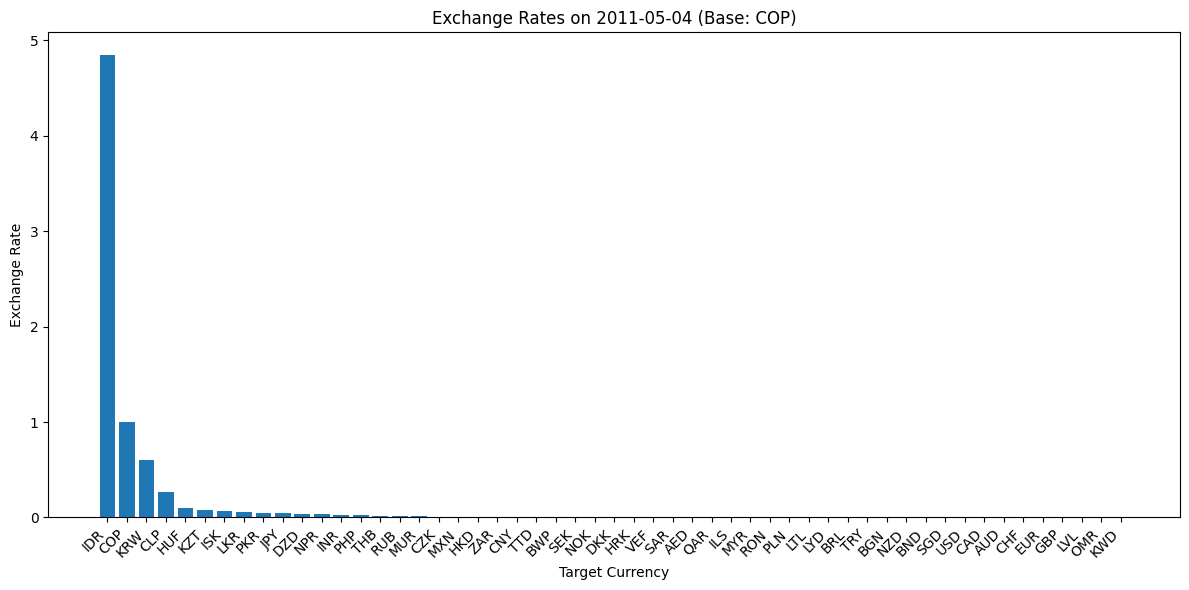

In [12]:
import matplotlib.pyplot as plt


sorted_rates = dict(sorted(exchange_rates.items(), key=lambda x: x[1], reverse=True))

#  plot of exchange rates over time
plt.figure(figsize=(12, 6))
plt.bar(sorted_rates.keys(), sorted_rates.values())
plt.xticks(rotation=45, ha='right')
plt.title(f"Exchange Rates on {date} (Base: {base})")
plt.ylabel("Exchange Rate")
plt.xlabel("Target Currency")
plt.tight_layout()
plt.show()

--------------------------------------------


# Side Quest 1 (10 XP): Lay Down Seeds for Those Who Follow – Logging

Even the greatest explorer must leave breadcrumbs for those who walk the path after them. Here you will construct an error log system, a journal that captures both triumphs and catastrophes.

Implement a robust logging system throughout your codebase to monitor:
- Successful currency downloads
- Parsing attempts and failures
- Skipped downloads (due to saved data or time out)
- Connection errors

## Notes from the Grand Master
- You do not need to do log hierarchy 
- Use log levels: INFO for progress, WARNING for skips, ERROR for failures



--------------------------------------------


# Side Quest 2 (10 XP): The quest of Reflection – Code Profiling

The final challenge for any Adventure is introspection — learning the nature of one's own power. In this side quest, you will profile your code, to discover its bottlenecks, inefficiencies, and optimization opportunities.

Use profiling tools to evaluate:
- Which functions are taking the most time
- How threads/processes are behaving
- Whether I/O is a bottleneck

*A random vendor appears* His invintory shows:
- A Profiler function - cProfile or Profile 
- A time module - timeit for micro-benchmarks
- A line profiler - line_profiler